In [1]:
# Imports + capability detection. The DSP path needs only numpy/librosa;
# torch/transformers/datasets are OPTIONAL and reported, never hard-required.
import numpy as np
import librosa

print("numpy   ", np.__version__)
print("librosa ", librosa.__version__)

TORCH_OK = HF_OK = DATASETS_OK = False
try:
    import torch; TORCH_OK = True
    print("torch   ", torch.__version__)
except Exception as e:
    print("torch    NOT available ->", type(e).__name__)
try:
    import transformers; HF_OK = True
    print("transformers", transformers.__version__)
except Exception as e:
    print("transformers NOT available ->", type(e).__name__)
try:
    import datasets; DATASETS_OK = True
    print("datasets", datasets.__version__)
except Exception as e:
    print("datasets NOT available ->", type(e).__name__)

# Pick the best device we have. (If MPS misbehaves in a pipeline, set "cpu".)
if TORCH_OK:
    device = ("cuda" if torch.cuda.is_available()
              else "mps" if torch.backends.mps.is_available() else "cpu")
else:
    device = "cpu"
pipe_device = 0 if device == "cuda" else -1   # HF pipeline wants an int
print("device  ", device, "| pipeline device:", pipe_device)

numpy    2.0.2
librosa  0.11.0
torch    2.11.0+cpu
transformers 5.12.1
datasets 4.0.0
device   cpu | pipeline device: -1


In [2]:
# Cosmetic plot style so spectrograms/waveforms read well in class.
import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams.update({
    "figure.dpi": 110, "figure.facecolor": "white",
    "axes.facecolor": "#FCFAF4", "axes.grid": True,
    "grid.color": "#E6E0D4", "axes.titleweight": "bold", "font.size": 10,
})
print("plot style ready")

plot style ready


In [3]:
# ---- Configuration -------------------------------------------------------
# Whisper sizes (speed vs accuracy): tiny < base < small < medium < large-v3 <
# large-v3-turbo. We default to a small ENGLISH model so class runs fast; flip
# to the production target for the exercise in §8.
ASR_MODEL_ID = "openai/whisper-base.en"          # fast classroom default
# ASR_MODEL_ID = "openai/whisper-large-v3-turbo" # production target

# TTS: a light VITS model, no speaker embeddings, runs on CPU. (API providers
# like OpenAI / ElevenLabs are shown as a pattern in §6.)
TTS_MODEL_ID = "facebook/mms-tts-eng"

SR = 16_000   # the speech sample rate the whole notebook standardizes on
print("ASR      :", ASR_MODEL_ID)
print("TTS      :", TTS_MODEL_ID)

ASR      : openai/whisper-base.en
TTS      : facebook/mms-tts-eng


# Let's create sound

In [5]:
import numpy as np
from IPython.display import Audio, display

sr = 100000
duration = 2

t = np.linspace(0, duration, sr * duration, endpoint=False)


deep_sound = 0.3 * np.sin(2 * np.pi * 100 * t)    # 100 Hz
sharp_sound = 0.3 * np.sin(2 * np.pi * 1000 * t)  # 1000 Hz

sharper_sound = 0.3 * np.sin(2 * np.pi * 10000 * t)  # 10000 Hz

upper_lim_sound = 0.3 * np.sin(2 * np.pi * 15000 * t)  # 15000 Hz

close_to_upper_lim_sound = 0.3 * np.sin(2 * np.pi * 18000 * t)  # 18000 Hz

print("Deep sound: slow vibration, 100 Hz")
display(Audio(deep_sound, rate=sr))

print("Sharp sound: fast vibration, 1000 Hz")
display(Audio(sharp_sound, rate=sr))

print("Sharper sound: very fast vibration, 10000 Hz")
display(Audio(sharper_sound, rate=sr))

print("Close to Upper limit sound: even faster vibration, 15000 Hz")
display(Audio(upper_lim_sound, rate=sr))

print("Close to Upper limit sound: even even faster vibration, 18000 Hz")
display(Audio(close_to_upper_lim_sound, rate=sr))


Deep sound: slow vibration, 100 Hz


Sharp sound: fast vibration, 1000 Hz


Sharper sound: very fast vibration, 10000 Hz


Close to Upper limit sound: even faster vibration, 15000 Hz


Close to Upper limit sound: even even faster vibration, 18000 Hz


In [6]:
combined_deep_and_sharp = deep_sound + sharp_sound

print("Combined deep and sharp sounds")
display(Audio(combined_deep_and_sharp, rate=sr))


Combined deep and sharp sounds


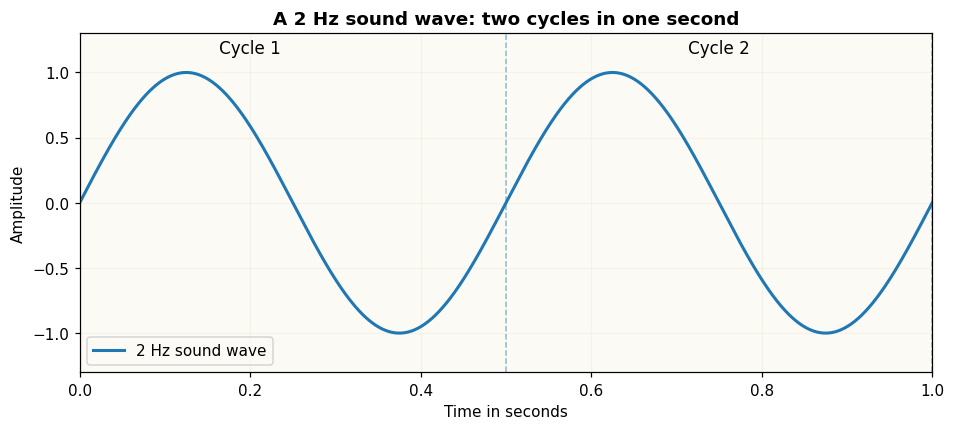

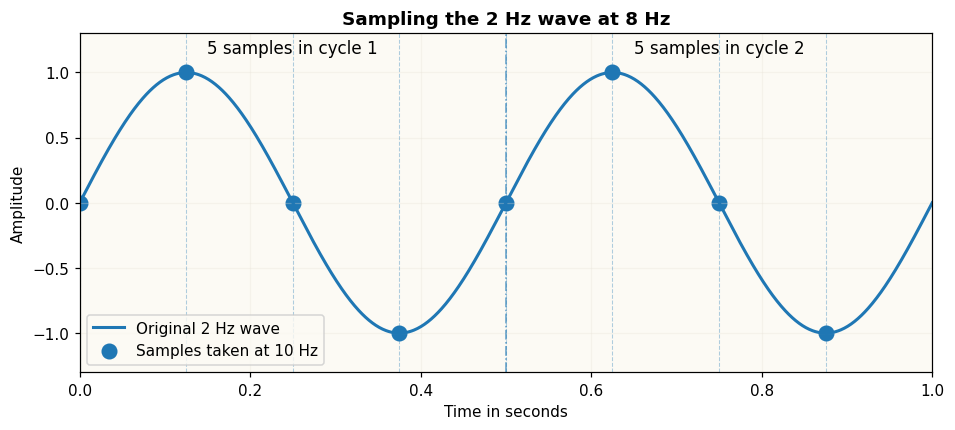

Sound frequency: 2 Hz = 2 cycles per second
Sampling rate: 8 Hz = 8 samples per second
Samples per cycle: 4.0
Sample times: [0.   0.12 0.25 0.38 0.5  0.62 0.75 0.88]
Sample values: [ 0.  1.  0. -1. -0.  1.  0. -1.]


In [7]:
import numpy as np
import matplotlib.pyplot as plt

# Toy values for teaching
sound_frequency = 2      # 2 cycles per second
sampling_rate = 8       # 10 samples per second
duration = 1.0           # seconds

# Smooth wave for visualization
t_smooth = np.linspace(0, duration, 1000)
y_smooth = np.sin(2 * np.pi * sound_frequency * t_smooth)

# Sampled points
t_samples = np.arange(0, duration, 1 / sampling_rate)
y_samples = np.sin(2 * np.pi * sound_frequency * t_samples)

# -----------------------------
# Plot 1: Just the 2 Hz wave
# -----------------------------
plt.figure(figsize=(10, 4))
plt.plot(t_smooth, y_smooth, linewidth=2, label="2 Hz sound wave")

# Mark the two cycles
plt.axvline(0.0, linestyle="--", linewidth=1, alpha=0.5)
plt.axvline(0.5, linestyle="--", linewidth=1, alpha=0.5)
plt.axvline(1.0, linestyle="--", linewidth=1, alpha=0.5)

plt.text(0.20, 1.15, "Cycle 1", ha="center", fontsize=11)
plt.text(0.75, 1.15, "Cycle 2", ha="center", fontsize=11)

plt.title("A 2 Hz sound wave: two cycles in one second")
plt.xlabel("Time in seconds")
plt.ylabel("Amplitude")
plt.xlim(0, 1)
plt.ylim(-1.3, 1.3)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# -----------------------------
# Plot 2: Same wave + sampling dots
# -----------------------------
plt.figure(figsize=(10, 4))
plt.plot(t_smooth, y_smooth, linewidth=2, label="Original 2 Hz wave")
plt.scatter(t_samples, y_samples, s=90, label="Samples taken at 10 Hz")

# Mark every sample time
for t in t_samples:
    plt.axvline(t, linestyle="--", linewidth=0.7, alpha=0.35)

# Mark cycle boundary
plt.axvline(0.5, linestyle="-.", linewidth=1, alpha=0.7)
plt.text(0.25, 1.15, "5 samples in cycle 1", ha="center", fontsize=11)
plt.text(0.75, 1.15, "5 samples in cycle 2", ha="center", fontsize=11)

plt.title("Sampling the 2 Hz wave at " + str(sampling_rate) + " Hz")
plt.xlabel("Time in seconds")
plt.ylabel("Amplitude")
plt.xlim(0, 1)
plt.ylim(-1.3, 1.3)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

print("Sound frequency:", sound_frequency, "Hz =", sound_frequency, "cycles per second")
print("Sampling rate:", sampling_rate, "Hz =", sampling_rate, "samples per second")
print("Samples per cycle:", sampling_rate / sound_frequency)
print("Sample times:", np.round(t_samples, 2))
print("Sample values:", np.round(y_samples, 2))

# Starting with a Real Data

In [8]:
# Load a real speech clip. We decode with soundfile (Audio(decode=False))
# to dodge the torchcodec/ffmpeg breakage, and cache locally for offline reruns.
import json, io
from pathlib import Path
import soundfile as sf
from IPython.display import Audio, display

CACHE = Path("audio_cache"); CACHE.mkdir(exist_ok=True)
WAV, META = CACHE / "librispeech_dummy.wav", CACHE / "librispeech_dummy_meta.json"

if WAV.exists() and META.exists():                       # 1) reuse local cache
    y, sr0 = sf.read(WAV, dtype="float32")
    meta = json.load(open(META)); ref_text, source = meta["ref_text"], meta["source"]
elif DATASETS_OK:                                        # 2) else fetch once
    from datasets import load_dataset, Audio as HFAudio
    ds = load_dataset("hf-internal-testing/librispeech_asr_dummy", "clean",
                      split="validation").cast_column("audio", HFAudio(decode=False))
    s = ds[0]; a = s["audio"]
    y, sr0 = sf.read(io.BytesIO(a["bytes"]) if a.get("bytes") else a["path"],
                     dtype="float32")
    y = np.asarray(y, np.float32); ref_text = s["text"]; source = "LibriSpeech dummy"
    sf.write(WAV, y, sr0, subtype="FLOAT")
    json.dump({"source": source, "sr": int(sr0), "ref_text": ref_text},
              open(META, "w"), indent=2)
else:
    raise RuntimeError("No cached clip and datasets unavailable -- run once with network.")

# Standardize on 16 kHz for the whole notebook (LibriSpeech is already 16k).
y16 = librosa.resample(y, orig_sr=sr0, target_sr=SR) if sr0 != SR else y

print(f"source   : {source}")
print(f"samples  : {len(y16):,}   sr: {SR} Hz   duration: {len(y16)/SR:.2f}s")
print(f"dtype    : {y16.dtype}   range: [{y16.min():+.3f}, {y16.max():+.3f}]   <- floats in [-1,1]")
print(f"reference: {ref_text!r}")
print("\n▶ listen:"); display(Audio(y16, rate=SR))

README.md:   0%|          | 0.00/520 [00:00<?, ?B/s]

clean/validation-00000-of-00001.parquet:   0%|          | 0.00/9.19M [00:00<?, ?B/s]

Generating validation split:   0%|          | 0/73 [00:00<?, ? examples/s]

source   : LibriSpeech dummy
samples  : 93,680   sr: 16000 Hz   duration: 5.86s
dtype    : float32   range: [-0.339, +0.388]   <- floats in [-1,1]
reference: 'MISTER QUILTER IS THE APOSTLE OF THE MIDDLE CLASSES AND WE ARE GLAD TO WELCOME HIS GOSPEL'

▶ listen:


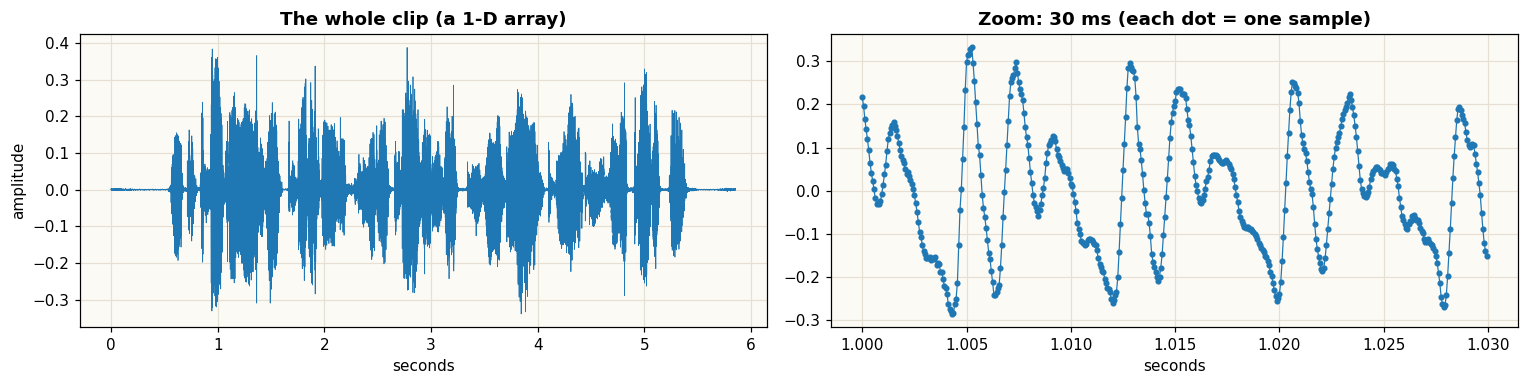

At 16000 Hz, 30 ms = 480 samples. The model reads ALL of them.


In [9]:
# It really is just numbers over time. Two pictures make that concrete:
import matplotlib.pyplot as plt
t = np.arange(len(y16)) / SR

fig, ax = plt.subplots(1, 2, figsize=(14, 3.6))
ax[0].plot(t, y16, lw=0.5)
ax[0].set(title="The whole clip (a 1-D array)", xlabel="seconds", ylabel="amplitude")

# Zoom to 30 ms: now you can SEE individual pressure samples (dots).
a, b = int(1.00 * SR), int(1.03 * SR)
ax[1].plot(t[a:b], y16[a:b], "-o", ms=3, lw=0.8)
ax[1].set(title="Zoom: 30 ms (each dot = one sample)", xlabel="seconds")
plt.tight_layout(); plt.show()

print(f"At {SR} Hz, 30 ms = {int(0.03*SR)} samples. The model reads ALL of them.")

#### 💡 Knowledge Check: Reading an audio array
**Q: A loader hands you a mono array of shape `(48000,)` for a clip you know is exactly 3 seconds long. What sample rate was it recorded at?**

A) 8 kHz  
B) 24 kHz  
C) 16 kHz  
D) 48 kHz  

In [10]:
# Three pure tones. A "tone" is literally one sine wave at one frequency.
import numpy as np
from IPython.display import Audio, display

dur   = 1.5
t     = np.linspace(0, dur, int(SR * dur), endpoint=False)   # SR = 16 kHz (from §0)
freqs = [220.0, 440.0, 660.0]          # A3, A4, E5  -> a simple chord
amps  = [1.0, 0.5, 0.33]               # higher tones a little quieter (natural)

tones = [a * np.sin(2 * np.pi * f * t) for f, a in zip(freqs, amps)]

for f, tone in zip(freqs, tones):
    print(f"{f:.0f} Hz pure tone:")
    display(Audio(0.3 * tone, rate=SR))   # 0.3 = gentle volume

220 Hz pure tone:


440 Hz pure tone:


660 Hz pure tone:


the three tones, summed into one wave:


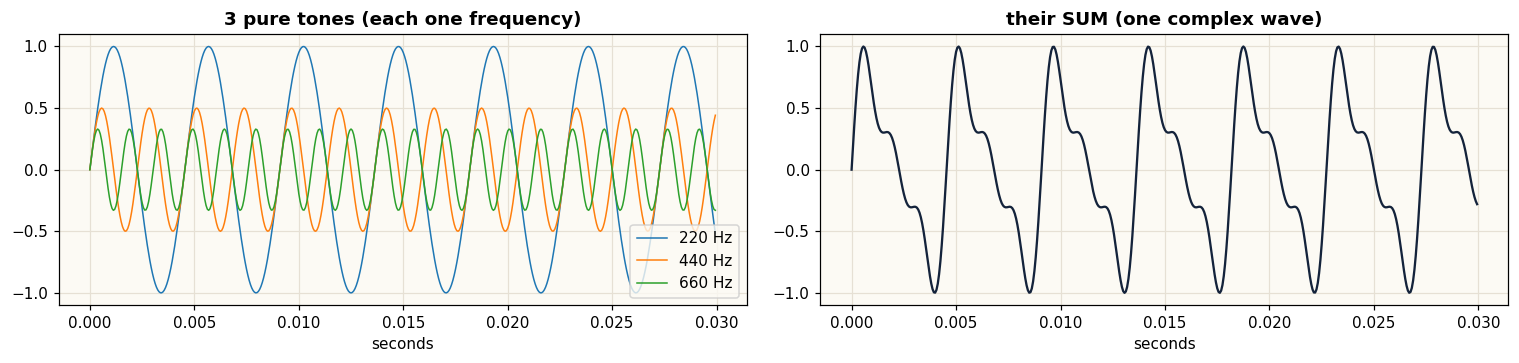

In [11]:
# Add them up. The sum is ONE array -- a single, more complex sound.
import matplotlib.pyplot as plt

mix = np.sum(tones, axis=0)
mix = mix / np.max(np.abs(mix))        # normalize into [-1, 1] so it will not clip

print("the three tones, summed into one wave:")
display(Audio(0.3 * mix, rate=SR))

# Zoom to ~30 ms so the shape is visible. One tone = a clean sine; the SUM is a
# repeating-but-complicated wave. Same information, just added together.
a, b = 0, int(0.03 * SR)
fig, ax = plt.subplots(1, 2, figsize=(14, 3.4))
for f, tone in zip(freqs, tones):
    ax[0].plot(t[a:b], tone[a:b], lw=1, label=f"{f:.0f} Hz")
ax[0].set(title="3 pure tones (each one frequency)", xlabel="seconds"); ax[0].legend()
ax[1].plot(t[a:b], mix[a:b], color="#14233B", lw=1.5)
ax[1].set(title="their SUM (one complex wave)", xlabel="seconds")
plt.tight_layout(); plt.show()

## Fast Fourier Transformation Videos

https://www.youtube.com/watch?v=spUNpyF58BY


https://www.youtube.com/watch?v=r6sGWTCMz2k&vl=en

(0.0, 1000.0)

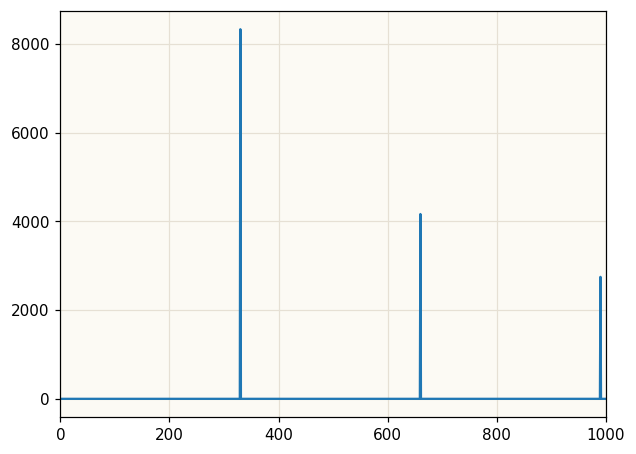

In [12]:
spectrum  = np.abs(np.fft.rfft(mix))
plt.plot(np.round(spectrum, 3))
plt.xlim(0, 1000)

In [13]:
# Two real clips, SAME sentence, different speaker: CMU Arctic bdl (US male)
# and slt (US female). We read them from audio_cache/ (already there); on a
# fresh machine the first run downloads them once. If the network is blocked we
# SYNTHESIZE a male/female vowel (source-filter) so this always runs offline.
import numpy as np, librosa, soundfile as sf
from pathlib import Path
from IPython.display import Audio, display

CACHE = Path("audio_cache"); CACHE.mkdir(exist_ok=True)
SRC = {
    "man":   ("audio_cache/man_bdl.wav",
              "http://festvox.org/cmu_arctic/cmu_arctic/cmu_us_bdl_arctic/wav/arctic_a0001.wav"),
    "woman": ("audio_cache/woman_slt.wav",
              "http://festvox.org/cmu_arctic/cmu_arctic/cmu_us_slt_arctic/wav/arctic_a0001.wav"),
}

def fetch(url, path):                          # best-effort; cache makes this rare
    try:
        import requests
        open(path, "wb").write(requests.get(
            url, timeout=30, headers={"User-Agent": "Mozilla/5.0"}).content)
    except Exception:
        from urllib.request import urlopen, Request
        open(path, "wb").write(urlopen(
            Request(url, headers={"User-Agent": "Mozilla/5.0"}), timeout=30).read())


voices = {}
for who, (path, url) in SRC.items():
    p = Path(path)
    try:
        if not p.exists():
            fetch(url, p)
        v, sr0 = sf.read(p, dtype="float32")
        if v.ndim > 1: v = v.mean(axis=1)                  # to mono
        voices[who] = librosa.resample(v, orig_sr=sr0, target_sr=SR) if sr0 != SR else v
    except Exception as e:
        print(f"{who}: download unavailable ({type(e).__name__}) ")


man, woman = voices["man"], voices["woman"]
for who, v in [("man", man), ("woman", woman)]:
    print(f"{who:5s}: {len(v) / SR:4.1f}s")
    display(Audio(v, rate=SR))

man  :  3.2s


woman:  3.4s


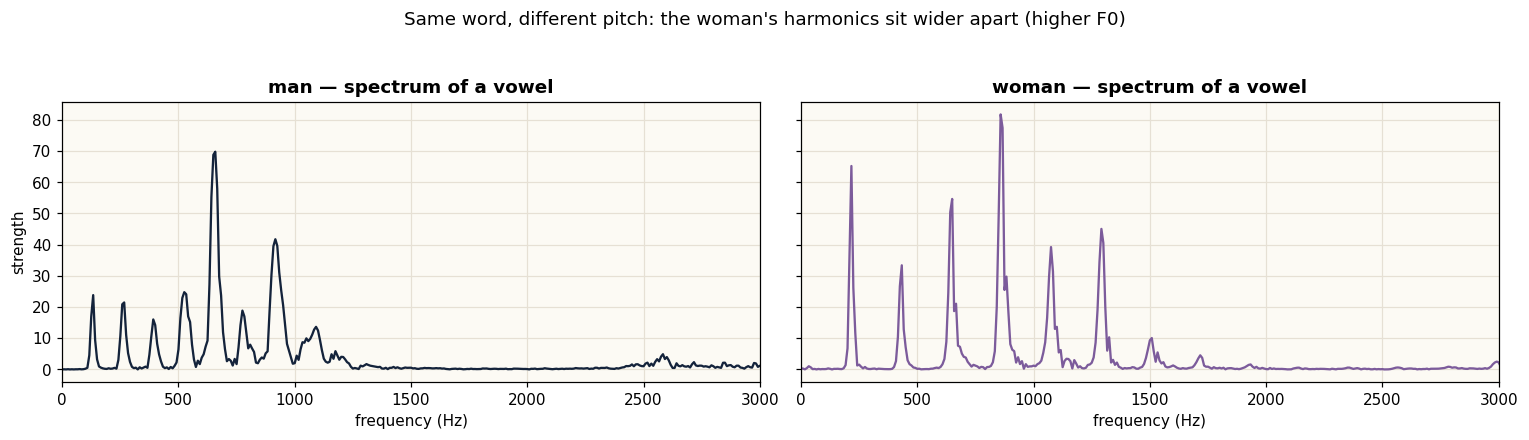

In [14]:
# Compare their frequency content. Take a short voiced (vowel) chunk from each
# and FFT it. The comb of spikes is F0 and its harmonics; the spacing between
# spikes IS the pitch -- the woman's comb is spaced wider (higher F0).
import matplotlib.pyplot as plt

def voiced_chunk(v, dur=0.12):
    i = int(np.argmax(np.abs(v)))             # near a loud (voiced) moment
    n = int(dur * SR); s = max(0, i - n // 2)
    return v[s:s + n]

fig, ax = plt.subplots(1, 2, figsize=(14, 3.8), sharey=True)
for col, (who, v, color) in zip(
        ax, [("man", man, "#14233B"), ("woman", woman, "#7C5B9B")]):
    seg = voiced_chunk(v)
    sp  = np.abs(np.fft.rfft(seg * np.hanning(len(seg))))
    fx  = np.fft.rfftfreq(len(seg), 1 / SR)
    col.plot(fx, sp, color=color)
    col.set(title=f"{who} — spectrum of a vowel", xlabel="frequency (Hz)", xlim=(0, 3000))
ax[0].set_ylabel("strength")
fig.suptitle("Same word, different pitch: the woman's harmonics sit wider apart (higher F0)", y=1.04)
plt.tight_layout(); plt.show()

Algorithm to isolate voiced sound and unvoiced sound

#### 1. RMS: how strong/loud is this short piece of audio?

RMS means Root Mean Square.

For every short frame of audio, we take all amplitude values inside that frame and summarize how energetic that frame is.


#### 2. ZCR: how often does the waveform cross zero?

ZCR means Zero-Crossing Rate.

The waveform has positive and negative values. A zero-crossing happens when the signal moves from positive to negative or negative to positive.


Frame length: 1024 samples = 64.0 ms
Hop length:   256 samples = 16.0 ms

RMS tells us how strong/loud each short frame is.
ZCR tells us how often the waveform crosses zero inside each frame.


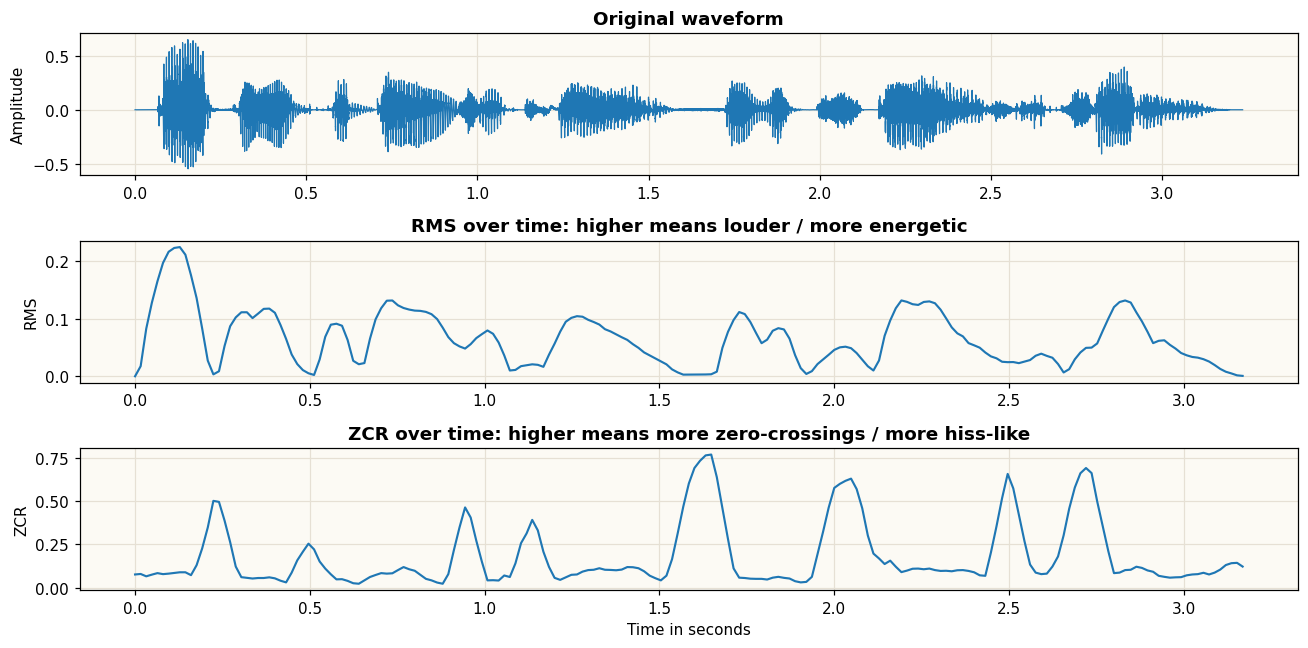

In [15]:
import numpy as np
import librosa
import matplotlib.pyplot as plt
from IPython.display import Audio, display

frame_length = 1024
hop_length = 256

frames = librosa.util.frame(man, frame_length=frame_length, hop_length=hop_length)

rms = np.sqrt(np.mean(frames ** 2, axis=0))

zcr = librosa.feature.zero_crossing_rate(
    man,
    frame_length=frame_length,
    hop_length=hop_length,
    center=False
)[0]

frame_times = librosa.frames_to_time(
    np.arange(len(rms)),
    sr=SR,
    hop_length=hop_length
)

frame_ms = 1000 * frame_length / SR
hop_ms = 1000 * hop_length / SR

print(f"Frame length: {frame_length} samples = {frame_ms:.1f} ms")
print(f"Hop length:   {hop_length} samples = {hop_ms:.1f} ms")
print()
print("RMS tells us how strong/loud each short frame is.")
print("ZCR tells us how often the waveform crosses zero inside each frame.")

plt.figure(figsize=(12, 6))

plt.subplot(3, 1, 1)
time = np.arange(len(man)) / SR
plt.plot(time, man, linewidth=0.8)
plt.title("Original waveform")
plt.ylabel("Amplitude")
plt.grid(True)

plt.subplot(3, 1, 2)
plt.plot(frame_times, rms, linewidth=1.4)
plt.title("RMS over time: higher means louder / more energetic")
plt.ylabel("RMS")
plt.grid(True)

plt.subplot(3, 1, 3)
plt.plot(frame_times, zcr, linewidth=1.4)
plt.title("ZCR over time: higher means more zero-crossings / more hiss-like")
plt.xlabel("Time in seconds")
plt.ylabel("ZCR")
plt.grid(True)

plt.tight_layout()
plt.show()

In [16]:
# Voiced vs unvoiced, made audible. Cut the man's clip into short frames and
# sort each as voiced (loud + few zero-crossings = periodic) or unvoiced
# (quieter + many zero-crossings = hiss), then play each group alone.
# (RMS + zero-crossings is a teaching heuristic only -- real systems use VAD, §4.)
import numpy as np, librosa
from IPython.display import Audio, display

frames = librosa.util.frame(man, frame_length=1024, hop_length=256)
rms = np.sqrt((frames ** 2).mean(axis=0))
zcr = (np.abs(np.diff(np.sign(frames), axis=0)) > 0).mean(axis=0)

speech   = rms > rms.max() * 0.10                       # loud enough to be speech
voiced   = speech & (zcr <  np.median(zcr[speech]))     # periodic -> vowels
unvoiced = speech & (zcr >= np.median(zcr[speech]))     # noisy    -> s / f / sh

def montage(mask):
    chunks = [man[i * 256:i * 256 + 256] for i, on in enumerate(mask) if on]
    return np.concatenate(chunks) if chunks else np.zeros(1, np.float32)

print("VOICED frames only — periodic, buzzy, vowel-like (this carries the pitch):")
display(Audio(montage(voiced), rate=SR))
print("UNVOICED frames only — hissy, noise-like, no pitch (the consonants):")
display(Audio(montage(unvoiced), rate=SR))

VOICED frames only — periodic, buzzy, vowel-like (this carries the pitch):


UNVOICED frames only — hissy, noise-like, no pitch (the consonants):


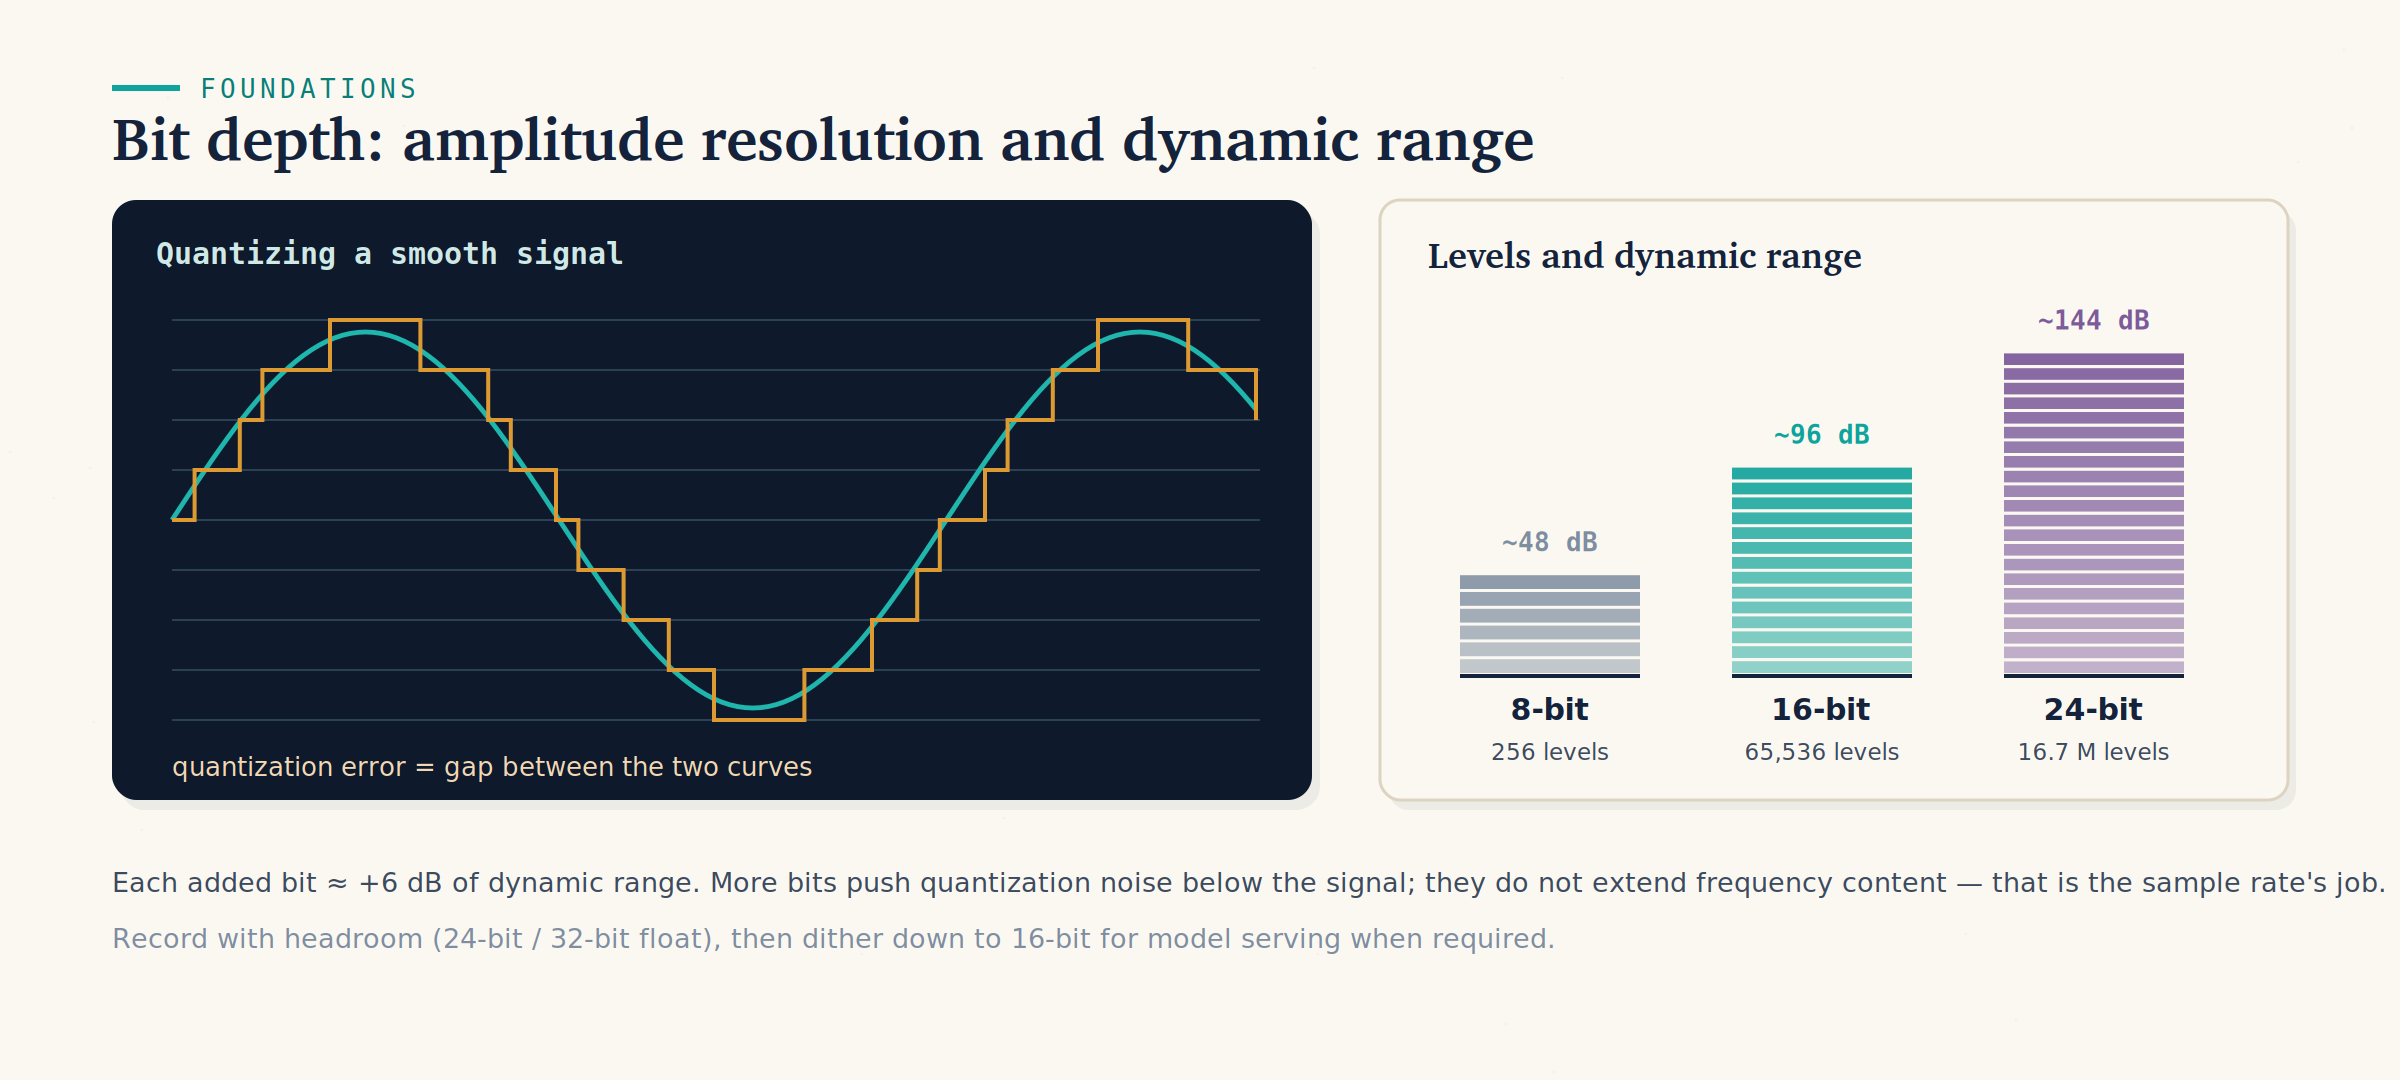

<sub><i>Bit depth sets amplitude resolution. ~6 dB dynamic range per bit; it does not add bandwidth.</i></sub>

Rounding each sample to a finite set of levels injects *quantization noise*;
SNR improves ~**6 dB per bit**.

In [17]:
# Quantize the real speech clip (y16, from §1) to fewer and fewer bits and
# listen to the noise floor rise. SNR climbs ~6 dB per bit, just as promised.
import numpy as np
from IPython.display import Audio, display

def quantize(sig, bits):
    levels = 2 ** bits
    s = np.clip(sig, -1, 1)
    s = (s + 1) / 2 * (levels - 1)             # map [-1, 1] -> [0, levels-1]
    return (np.round(s) / (levels - 1)) * 2 - 1  # snap to nearest rung, map back

print("original (float32, ~transparent):"); display(Audio(y16, rate=SR))
print(f"{'bits':>4} {'levels':>8} {'SNR(dB)':>8}")
for b in [16, 8, 4, 2]:
    q = quantize(y16, b)
    snr = 20 * np.log10(np.linalg.norm(y16) / (np.linalg.norm(y16 - q) + 1e-12))
    print(f"{b:>4} {2 ** b:>8} {snr:>8.1f}")
    display(Audio(q, rate=SR))

original (float32, ~transparent):


bits   levels  SNR(dB)
  16    65536     72.5


   8      256     27.8


   4       16      2.0


   2        4    -13.7


# raw audio waveform
#         ↓
# short overlapping frames
#         ↓
# frequency-energy analysis
#         ↓
# mel frequency compression
#         ↓
# log-mel spectrogram
#         ↓
# speech model encoder

mel spectrogram = spectrogram compressed into human-hearing-friendly frequency bands

log-mel shape: (80, 586) = (mel bands, time frames)
frames/sec   : 100  (~100, as promised)


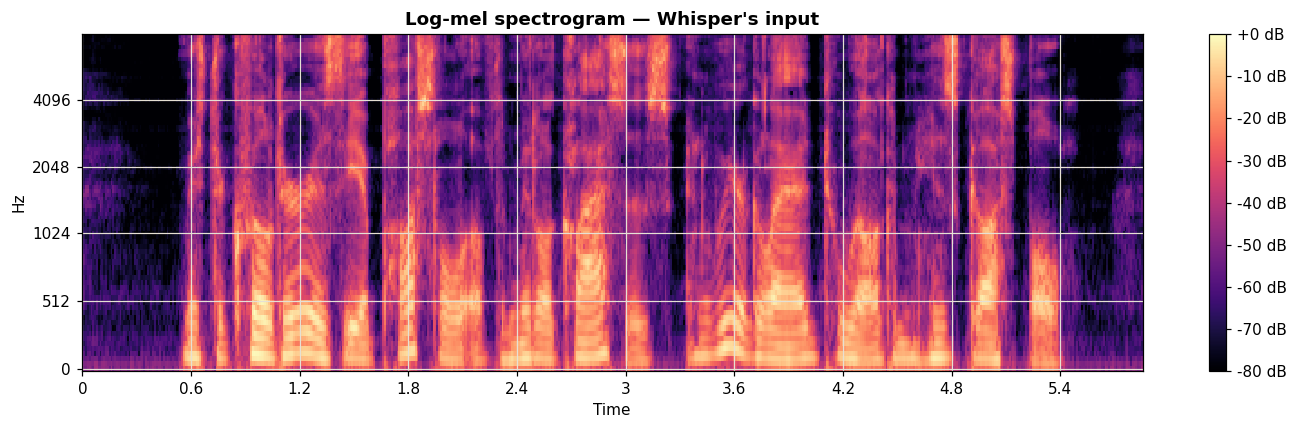

as a model tensor: (1, 80, 586) (batch, 80 mel, frames)


In [18]:
import librosa.display

# Whisper-style front-end settings (you almost never change these).
n_mels,  hop, win = 80, 160, 400   # 400=25ms, 160=10ms at 16 kHz

mel = librosa.feature.melspectrogram(
    y=y16, sr=SR,  hop_length=hop, win_length=win,
    n_mels=n_mels, fmin=0, fmax=8000, power=2.0)    # power spectrogram
log_mel = librosa.power_to_db(mel, ref=np.max)      # the "log" step (in dB)

print("log-mel shape:", log_mel.shape, "= (mel bands, time frames)")
print(f"frames/sec   : {log_mel.shape[1] / (len(y16)/SR):.0f}  (~100, as promised)")

plt.figure(figsize=(13, 4))
librosa.display.specshow(log_mel, sr=SR, hop_length=hop,
                         x_axis="time", y_axis="mel", fmax=8000, cmap="magma")
plt.colorbar(format="%+2.0f dB"); plt.title("Log-mel spectrogram — Whisper's input")
plt.tight_layout(); plt.show()

# This (80, T) image is ALL the encoder reads. As a tensor it's just:
#   (batch, mel, time)  ==  log_mel[None, :, :]
print("as a model tensor:", (1,) + log_mel.shape, "(batch, 80 mel, frames)")

# API USAGE Of Sounds

In [19]:
# Load Whisper, guarded. Defines _ASR_READY, processor, model, hyp for below.
_ASR_READY = False
processor = model = hyp = None
if HF_OK and TORCH_OK:
    try:
        from transformers import WhisperProcessor, WhisperForConditionalGeneration
        processor = WhisperProcessor.from_pretrained(ASR_MODEL_ID)
        model = WhisperForConditionalGeneration.from_pretrained(
            ASR_MODEL_ID).to(device).eval()
        _ASR_READY = True
        n = sum(p.numel() for p in model.parameters()) / 1e6
        print(f"loaded {ASR_MODEL_ID}  (~{n:.0f}M params) on {device}")
    except Exception as e:
        print("ASR model not loaded (", type(e).__name__, "). Re-run with network.")
else:
    print("[skipped] transformers/torch unavailable. §4+ print notices; §1-§3 are real.")

preprocessor_config.json:   0%|          | 0.00/185k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.94k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/805 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/798k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.41M [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/1.83k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/290M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/245 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/1.53k [00:00<?, ?B/s]

loaded openai/whisper-base.en  (~73M params) on cpu


In [20]:
feats = processor(y16, sampling_rate=16_000,
                  return_tensors="pt").input_features.to(device)
print("input_features:", tuple(feats.shape), "= (batch, 80 mel, frames)")
with torch.no_grad():
    ids = model.generate(feats, max_new_tokens=128)
hyp = processor.batch_decode(ids, skip_special_tokens=True)[0].strip()
print("\nhypothesis:", hyp)
print("reference :", ref_text)

[transformers] Using custom `forced_decoder_ids` from the (generation) config. This is deprecated in favor of the `task` and `language` flags/config options.
[transformers] The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


input_features: (1, 80, 3000) = (batch, 80 mel, frames)


[transformers] Both `max_new_tokens` (=128) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] A custom logits processor of type <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> has been passed to `.generate()`, but it was also created in `.generate()`, given its parameterization. The custom <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> will take precedence. Please check the docstring of <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> to see related `.generate()` flags.
[transformers] A custom logits processor of type <class 'transformers.generation.logits_process.SuppressTokensAtBeginLogitsProcessor'> has been passed to `.generate()`, but it was also created in `.generate()`, given its parameterization. The cus


hypothesis: Mr. Quilter is the apostle of the middle classes, and we are glad to welcome his gospel.
reference : MISTER QUILTER IS THE APOSTLE OF THE MIDDLE CLASSES AND WE ARE GLAD TO WELCOME HIS GOSPEL


# Open AI API

In [21]:
import os, json
from dotenv import load_dotenv

import textwrap



def pretty_print(*args):
    text = " ".join(str(arg) for arg in args)
    try:
        print(textwrap.fill(text, width=80))
    except Exception as e:
        print(text)  # fallback to normal print if text is not a string



load_dotenv('openai_key.env')  # reads .env file in the current directory

api_key = os.getenv("OPENAI_API_KEY")

if not api_key:
    raise ValueError(
        "OPENAI_API_KEY not found! "
        "Make sure you have a .env file with: OPENAI_API_KEY=sk-..."
    )

pretty_print("API key loaded successfully.")

API key loaded successfully.


In [22]:
from openai import OpenAI

client = OpenAI()


In [24]:
from pathlib import Path

speech_file_path = Path("tutor_voice.mp3")

with client.audio.speech.with_streaming_response.create(
    model="gpt-4o-mini-tts",
    voice="nova",  # e.g. alloy, verse, aria (varies)
    input="Hello students! Today we will explore AI that can see, listen, and speak."
) as response:
    response.stream_to_file(speech_file_path)

print("Saved speech to:", speech_file_path)


Saved speech to: tutor_voice.mp3


In [25]:
from pathlib import Path

audio_file_path = Path("test_audio.wav")

with open(audio_file_path, "rb") as audio_file:
    transcription = client.audio.transcriptions.create(
        model="gpt-4o-transcribe",
        file=audio_file,
    )

print("Transcribed text:", transcription.text)


if transcription.usage:
    print("Input tokens:", getattr(transcription.usage, "input_tokens", None))
    print("Output tokens:", getattr(transcription.usage, "output_tokens", None))
    print("Total tokens:", getattr(transcription.usage, "total_tokens", None))

    details = getattr(transcription.usage, "input_token_details", None)
    if details:
        print("Audio tokens:", getattr(details, "audio_tokens", None))
        print("Text tokens:", getattr(details, "text_tokens", None))

Transcribed text: Hello, testing one two three.
Input tokens: 34
Output tokens: 9
Total tokens: 43
Audio tokens: 34
Text tokens: 0


In [26]:
# # closed captions and subtitles

# parakeet size 430MB > Whisper

# Word Error Rate : it prediccted right now 10 words, how many of em matched reference.